In [177]:
import pandas as pd
import numpy as np
import sys   
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # add project root so src is importable
import matplotlib.pyplot as plt   
import seaborn as sns 

from src.config import (
    CUSTOMERS_TRAIN, LOANS_CLEAN, TRANSACTIONS_CLEAN, TRAIN_IDS,
)

train_cust = pd.read_parquet(CUSTOMERS_TRAIN)
loans = pd.read_parquet(LOANS_CLEAN)
txns  = pd.read_parquet(TRANSACTIONS_CLEAN)

train_ids   = pd.read_parquet(TRAIN_IDS)["customer_id"]
loans_train = loans[loans["customer_id"].isin(train_ids)]
txns_train  = txns[txns["customer_id"].isin(train_ids)] 

            count        mean        std    min    25%    50%    75%    max
defaulted                                                                  
0          5491.0  473.214351  46.200889  324.0  441.0  470.0  503.0  632.0
1           903.0  450.317829  38.521624  329.0  424.0  449.0  474.0  592.0


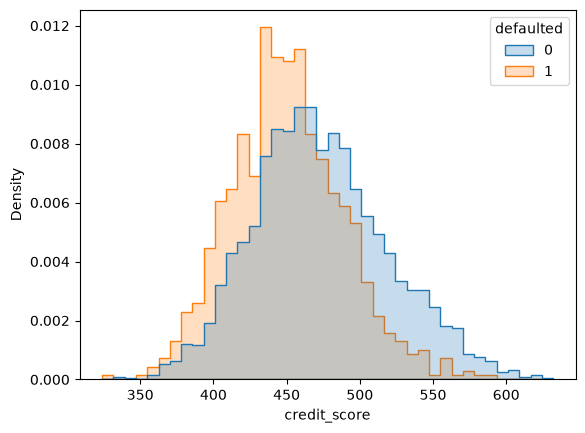

In [178]:
# Attach each loan's customer score
loans_scored = loans_train.merge(
    train_cust[["customer_id", "credit_score"]],
    on="customer_id", how="left"
)

# Compare the two groups
print(loans_scored.groupby("defaulted")["credit_score"].describe())

# See the shape
sns.histplot(data=loans_scored, x="credit_score", hue="defaulted",
             bins=40, element="step", stat="density", common_norm=False)
plt.show()

EDA

In [179]:
train_cust.shape

(12000, 23)

In [180]:
train_cust.info()

<class 'pandas.DataFrame'>
Index: 12000 entries, 0 to 14999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             12000 non-null  str           
 1   age                     12000 non-null  float64       
 2   region                  12000 non-null  category      
 3   city                    12000 non-null  category      
 4   segment_true            12000 non-null  category      
 5   onboarding_date         12000 non-null  datetime64[us]
 6   wallet_tenure_months    12000 non-null  float64       
 7   declared_income_band    12000 non-null  category      
 8   avg_monthly_inflow_pkr  12000 non-null  float64       
 9   dependents              12000 non-null  int64         
 10  smartphone_user         12000 non-null  int64         
 11  avg_monthly_txns        12000 non-null  float64       
 12  complaints_12m          12000 non-null  int64         
 13  fa

In [181]:
train_cust["churned_12m"].value_counts(normalize=True)

churned_12m
N    0.922959
Y    0.077041
Name: proportion, dtype: float64

In [182]:
loans_train["defaulted"].value_counts(normalize=True)

defaulted
0    0.858774
1    0.141226
Name: proportion, dtype: float64

In [183]:
train_cust.describe().T

,count,mean,min,25%,50%,75%,max,std
age,12000.0,32.721167,18.0,27.0,33.0,38.0,66.0,8.47948
onboarding_date,12000,2023-01-26 16:57:50.400000,2017-07-13 00:00:00,2022-06-12 18:00:00,2023-06-18 00:00:00,2024-01-23 00:00:00,2024-06-01 00:00:00,NaN
wallet_tenure_months,12000.0,28.567667,9.0,17.0,24.0,35.0,96.0,16.113557
avg_monthly_inflow_pkr,12000.0,38545.408333,8000.0,21000.0,31700.0,47700.0,343700.0,26667.529482
dependents,12000.0,1.604333,0.0,1.0,1.0,2.0,8.0,1.267115
smartphone_user,12000.0,0.8325,0.0,1.0,1.0,1.0,1.0,0.373437
avg_monthly_txns,12000.0,20.117358,2.5,9.7,13.4,21.1,147.6,17.601385
complaints_12m,12000.0,0.61575,0.0,0.0,0.0,1.0,5.0,0.786121
failed_txns_12m,12000.0,1.103667,0.0,0.0,1.0,2.0,8.0,1.044515
has_savings,12000.0,0.41925,0.0,0.0,0.0,1.0,1.0,0.493457


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'onboarding_date'}>,
        <Axes: title={'center': 'wallet_tenure_months'}>,
        <Axes: title={'center': 'avg_monthly_inflow_pkr'}>],
       [<Axes: title={'center': 'dependents'}>,
        <Axes: title={'center': 'smartphone_user'}>,
        <Axes: title={'center': 'avg_monthly_txns'}>,
        <Axes: title={'center': 'complaints_12m'}>],
       [<Axes: title={'center': 'failed_txns_12m'}>,
        <Axes: title={'center': 'has_savings'}>,
        <Axes: title={'center': 'savings_balance_pkr'}>,
        <Axes: title={'center': 'has_insurance'}>],
       [<Axes: title={'center': 'credit_score'}>,
        <Axes: title={'center': 'age_missing'}>,
        <Axes: title={'center': 'income_band_missing'}>,
        <Axes: title={'center': 'tenure_years'}>],
       [<Axes: title={'center': 'is_whale'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

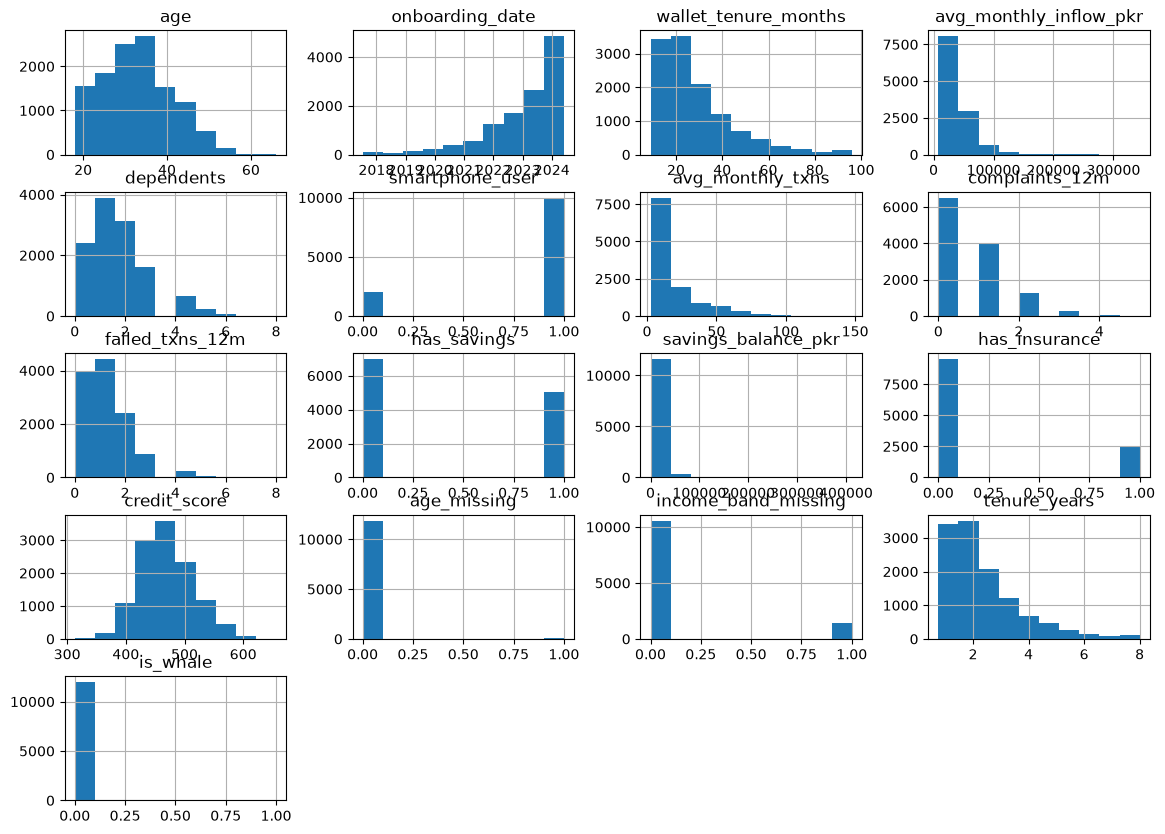

In [184]:
train_cust.hist(figsize=(14,10), bins=10) 

C:\Program Files\KMSpico\temp\ipykernel_11628\1503381913.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for cols in train_cust.select_dtypes(["category","object","bool"]).drop(columns="customer_id"):


region
Punjab         0.421750
Sindh          0.230833
KP             0.142083
Islamabad      0.104000
Balochistan    0.051167
AJK-GB         0.050167
Name: proportion, dtype: float64


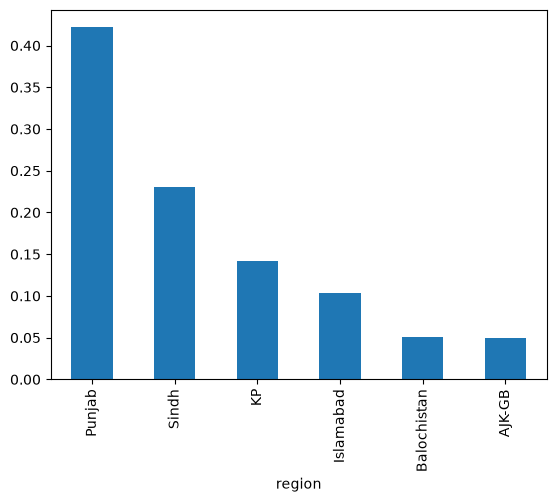

city
Islamabad       0.104000
Lahore          0.085917
Sargodha        0.085583
Faisalabad      0.085333
Multan          0.083750
Rawalpindi      0.081167
Karachi         0.078667
Hyderabad       0.076917
Sukkur          0.075250
Peshawar        0.049250
Abbottabad      0.047167
Mardan          0.045667
Gilgit          0.027333
Gwadar          0.025917
Quetta          0.025250
Muzaffarabad    0.022833
Name: proportion, dtype: float64


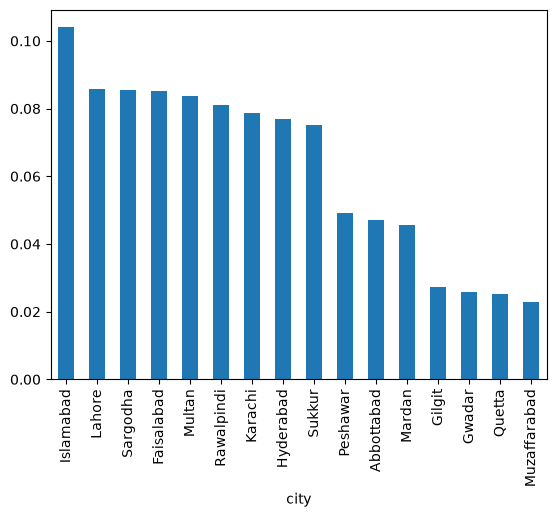

segment_true
payroll     0.345833
saver       0.251833
merchant    0.201333
borrower    0.201000
Name: proportion, dtype: float64


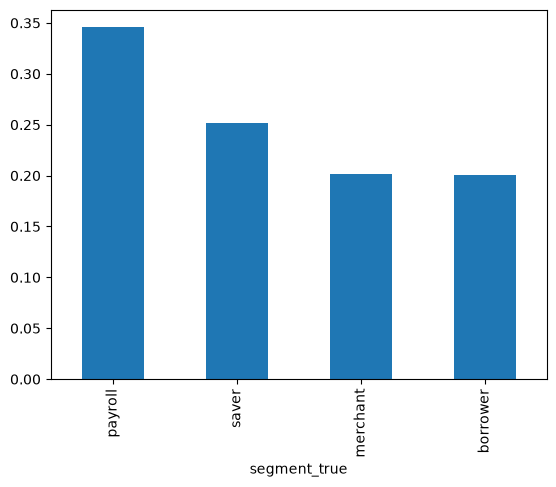

declared_income_band
25-50k      0.479167
<25k        0.298250
50-100k     0.183167
100-250k    0.038750
250k+       0.000667
Name: proportion, dtype: float64


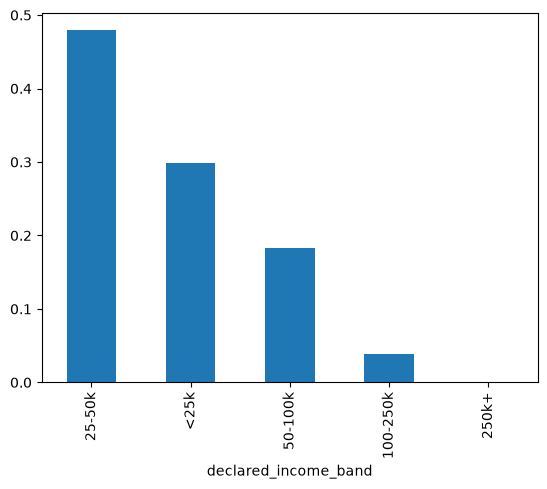

churned_12m
N    0.922959
Y    0.077041
Name: proportion, dtype: float64


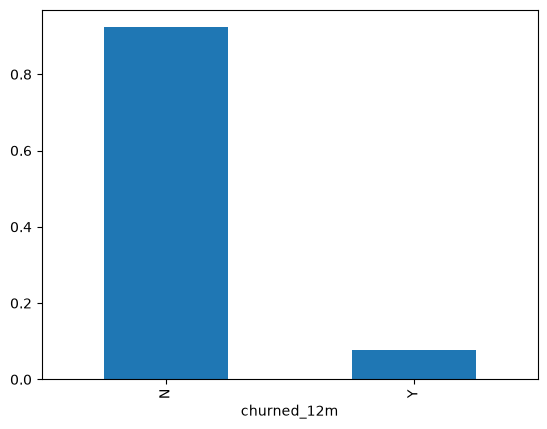

In [185]:
for cols in train_cust.select_dtypes(["category","object","bool"]).drop(columns="customer_id"):
    col=train_cust[cols].value_counts(normalize=True)
    print(col)
    col.plot(kind="bar")
    plt.show()

In [186]:
col.describe(include=["category","object"])

count    2.000000
mean     0.500000
std      0.598155
min      0.077041
25%      0.288520
50%      0.500000
75%      0.711480
max      0.922959
Name: proportion, dtype: float64

In [187]:
# - Balochistan ~325 loans → H4 may be underpowered, check before concluding
# - 250k+ has 8 customers → fold into 100-250k
# - city nests inside region → use region, drop city
# - churn 92/8 → accuracy banned, use class weights

In [188]:
loans_train.describe()

,disbursed_date,amount_pkr,term_months,interest_rate_pct,inflow_to_loan_ratio,defaulted
count,6394,6394.000000,6394.000000,6394.000000,6394.000000,6394.000000
mean,2024-12-15 10:17:58.761338,69753.369878,3.895996,29.000532,2.549820,0.141226
min,2024-07-01 00:00:00,2000.000000,1.000000,18.000000,0.010000,0.000000
25%,2024-09-24 00:00:00,12969.000000,1.000000,26.100000,0.350000,0.000000
50%,2024-12-17 00:00:00,23418.000000,3.000000,29.300000,0.840000,0.000000
75%,2025-03-09 00:00:00,85230.500000,6.000000,32.200000,2.547500,0.000000
max,2025-05-26 00:00:00,399599.000000,12.000000,36.000000,49.050000,1.000000
std,NaN,94897.336167,3.227682,4.295872,4.462391,0.348282


array([[<Axes: title={'center': 'disbursed_date'}>,
        <Axes: title={'center': 'amount_pkr'}>],
       [<Axes: title={'center': 'term_months'}>,
        <Axes: title={'center': 'interest_rate_pct'}>],
       [<Axes: title={'center': 'inflow_to_loan_ratio'}>,
        <Axes: title={'center': 'defaulted'}>]], dtype=object)

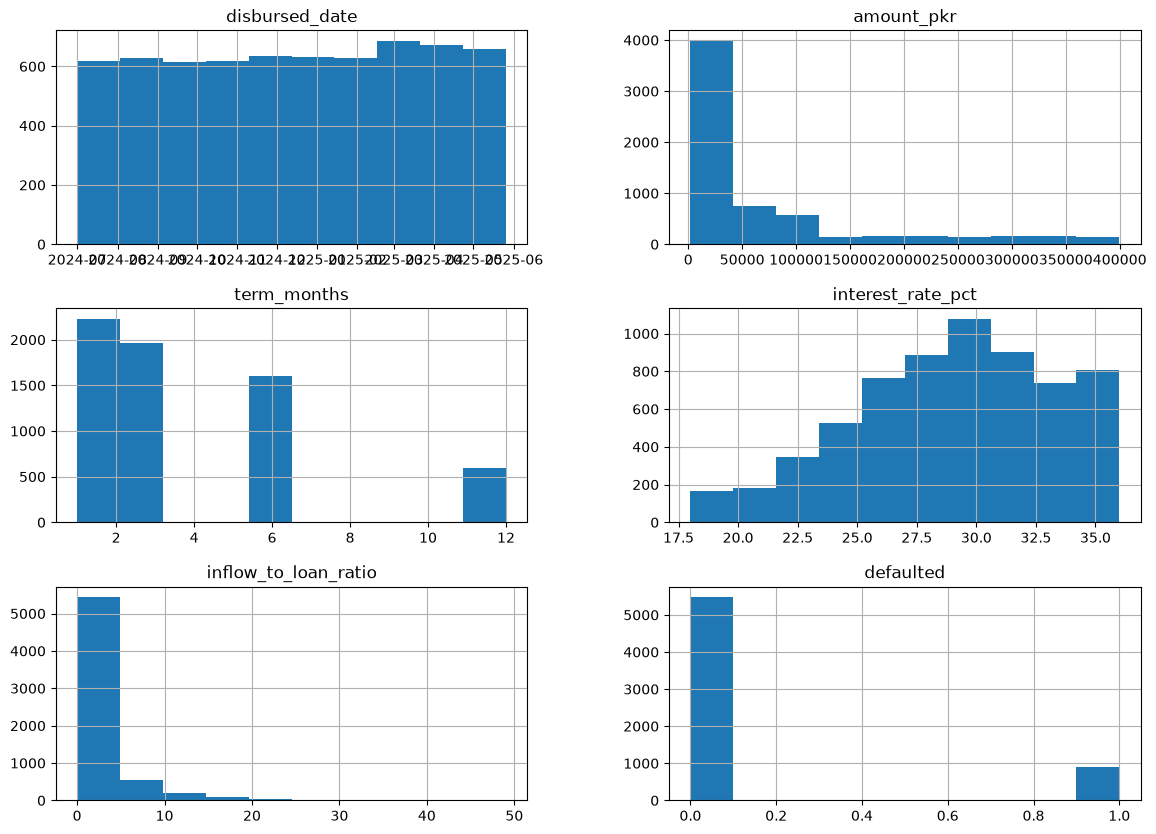

In [189]:
loans_train.hist(figsize=(14,10), bins=10) 

In [190]:
loans_train.info()

<class 'pandas.DataFrame'>
Index: 6394 entries, 3 to 7998
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   loan_id               6394 non-null   str           
 1   customer_id           6394 non-null   str           
 2   disbursed_date        6394 non-null   datetime64[us]
 3   purpose               6394 non-null   category      
 4   amount_pkr            6394 non-null   float64       
 5   term_months           6394 non-null   int64         
 6   interest_rate_pct     6394 non-null   float64       
 7   inflow_to_loan_ratio  6394 non-null   float64       
 8   defaulted             6394 non-null   int8          
 9   amount_suspect        6394 non-null   bool          
dtypes: bool(1), category(1), datetime64[us](1), float64(3), int64(1), int8(1), str(2)
memory usage: 507.4 KB


C:\Program Files\KMSpico\temp\ipykernel_11628\2261840549.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for cols in loans_train.select_dtypes(["category","object","bool"]).drop(columns=["customer_id","loan_id"]):


purpose
nano_loan           0.451986
merchant_advance    0.225837
device_finance      0.176259
emergency           0.145918
Name: proportion, dtype: float64


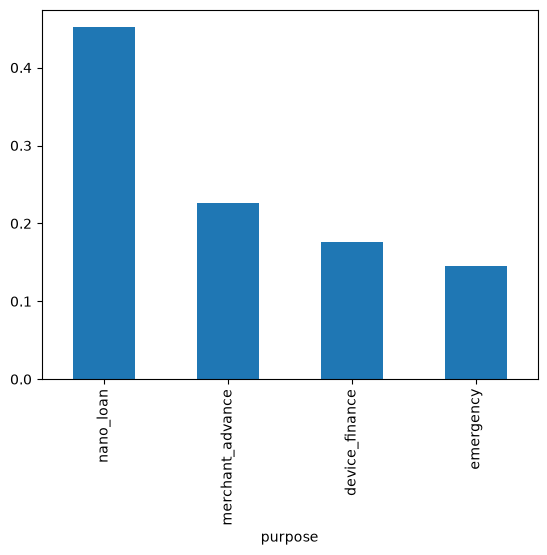

amount_suspect
False    1.0
Name: proportion, dtype: float64


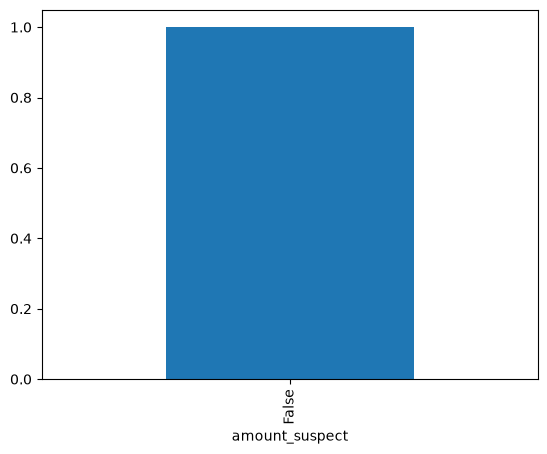

In [191]:
for cols in loans_train.select_dtypes(["category","object","bool"]).drop(columns=["customer_id","loan_id"]):
    col=loans_train[cols].value_counts(normalize=True)
    print(col)
    col.plot(kind="bar")
    plt.show() 

count                         12000
mean     2023-01-26 16:57:50.400000
min             2017-07-13 00:00:00
25%             2022-06-12 18:00:00
50%             2023-06-18 00:00:00
75%             2024-01-23 00:00:00
max             2024-06-01 00:00:00
Name: onboarding_date, dtype: object


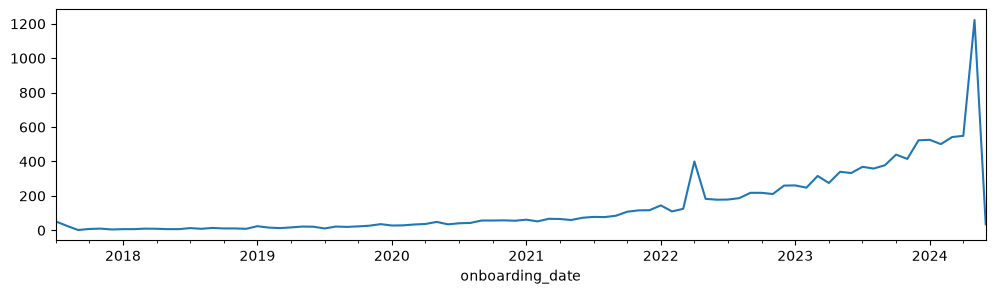

count                          6394
mean     2024-12-15 10:17:58.761338
min             2024-07-01 00:00:00
25%             2024-09-24 00:00:00
50%             2024-12-17 00:00:00
75%             2025-03-09 00:00:00
max             2025-05-26 00:00:00
Name: disbursed_date, dtype: object


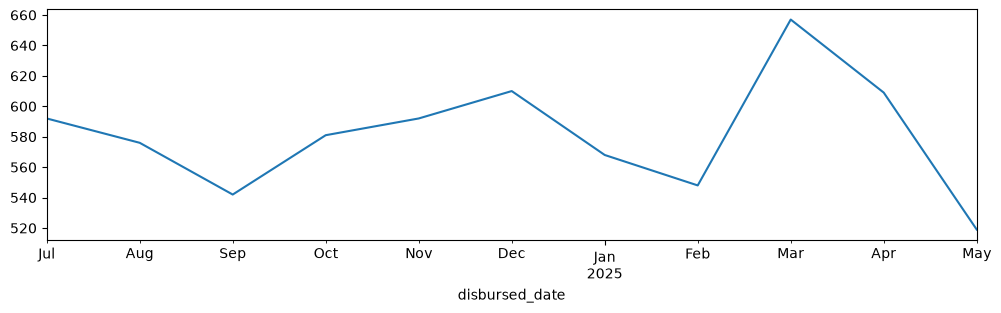

count                        122760
mean     2024-12-10 03:53:51.906158
min             2024-07-01 00:00:00
25%             2024-09-01 00:00:00
50%             2024-12-01 00:00:00
75%             2025-03-01 00:00:00
max             2025-06-01 00:00:00
Name: month, dtype: object


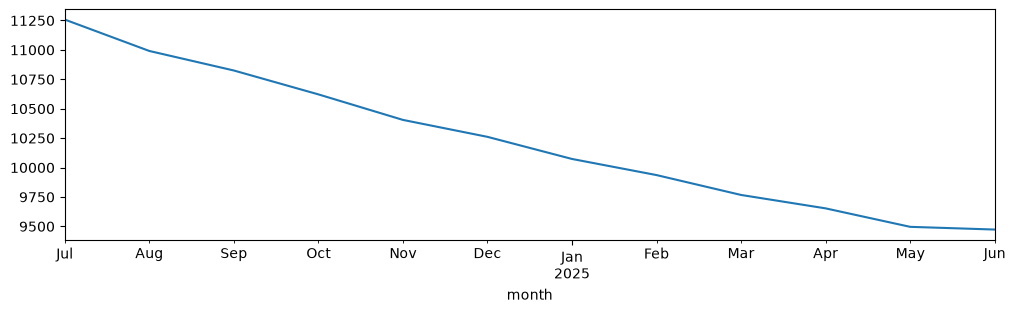

In [192]:
# onboarding_date
print(train_cust["onboarding_date"].describe())
train_cust["onboarding_date"].dt.to_period("M").value_counts().sort_index().plot(figsize=(12,3))
plt.show()

# disbursed_date
print(loans_train["disbursed_date"].describe())
loans_train["disbursed_date"].dt.to_period("M").value_counts().sort_index().plot(figsize=(12,3))
plt.show()

# month
print(txns_train["month"].describe())
txns_train["month"].dt.to_period("M").value_counts().sort_index().plot(figsize=(12,3))
plt.show()

           txn_count  txn_value_pkr
count  122760.000000  122760.000000
mean        7.111233   17302.733708
std         6.884229   22058.675019
min         0.000000       0.000000
25%         3.000000    5100.000000
50%         5.000000   10260.000000
75%         9.000000   20710.000000
max        81.000000  577870.000000


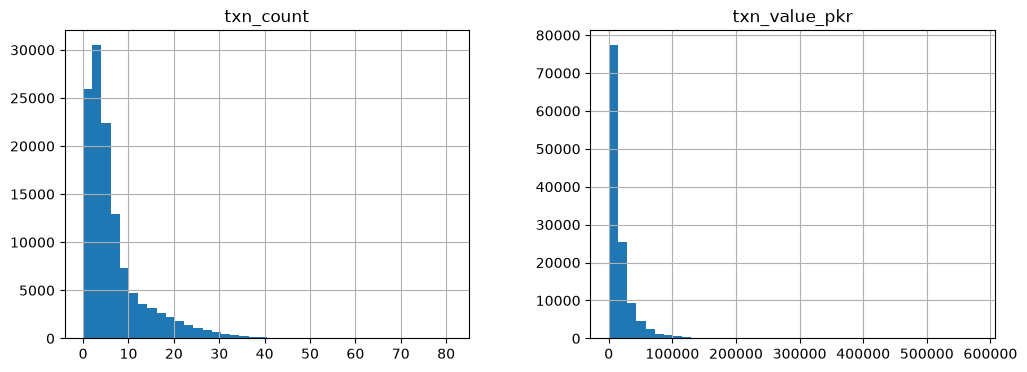

            total_txns  total_value  customers
month                                         
2024-07-01       75084  169009290.0      11258
2024-08-01       73382  166517630.0      10991
2024-09-01       72379  162326570.0      10825
2024-10-01       71324  160695580.0      10622
2024-11-01       69473  157536510.0      10405
2024-12-01       68516  156478330.0      10261
2025-01-01       67977  154872010.0      10073
2025-02-01       67169  150794100.0       9936
2025-03-01       65152  147151170.0       9767
2025-04-01       94457  310871490.0       9653
2025-05-01       64689  145971150.0       9496
2025-06-01       83373  241859760.0       9473


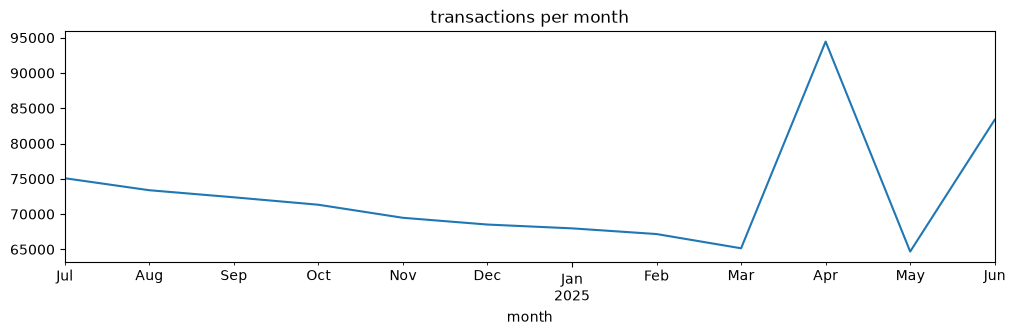

         total_txns   total_value      avg_txns      avg_value  active_months
count  12000.000000  1.200000e+04  12000.000000   12000.000000   12000.000000
mean      72.747917  1.770070e+05      7.082982   17202.802448      10.230000
std       67.181636  1.688142e+05      6.265763   15754.647996       1.962886
min        3.000000  4.130000e+03      0.428571     590.000000       4.000000
25%       33.000000  7.679750e+04      3.363636    7785.625000       9.000000
50%       49.000000  1.180300e+05      4.750000   11370.000000      11.000000
75%       80.000000  1.984725e+05      7.583333   19183.390152      12.000000
max      609.000000  1.864750e+06     52.300000  155395.833333      12.000000


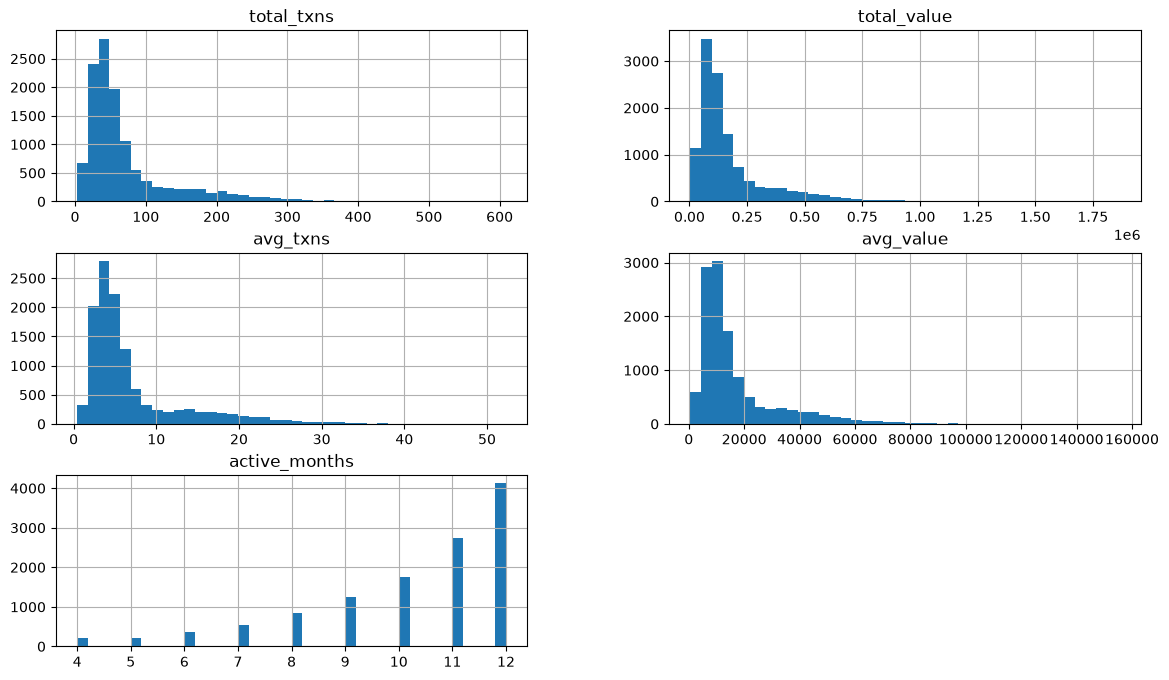

In [193]:
# ── 1. TRANSACTIONS — per customer-month (the raw grain) ──
print(txns_train[["txn_count", "txn_value_pkr"]].describe())
txns_train[["txn_count", "txn_value_pkr"]].hist(figsize=(12,4), bins=40)
plt.show()

per_month = txns_train.groupby("month").agg(
    total_txns  = ("txn_count", "sum"),
    total_value = ("txn_value_pkr", "sum"),
    customers   = ("customer_id", "nunique"),
)
print(per_month)
per_month["total_txns"].plot(figsize=(12,3), title="transactions per month")
plt.show() 


# ── 2. TRANSACTIONS — per customer (roll up first) ──
per_cust = txns_train.groupby("customer_id").agg(
    total_txns   = ("txn_count", "sum"),
    total_value  = ("txn_value_pkr", "sum"),
    avg_txns     = ("txn_count", "mean"),
    avg_value    = ("txn_value_pkr", "mean"),
    active_months= ("month", "nunique"),
)

print(per_cust.describe())
per_cust.hist(figsize=(14,8), bins=40)
plt.show()

BIVARIATE

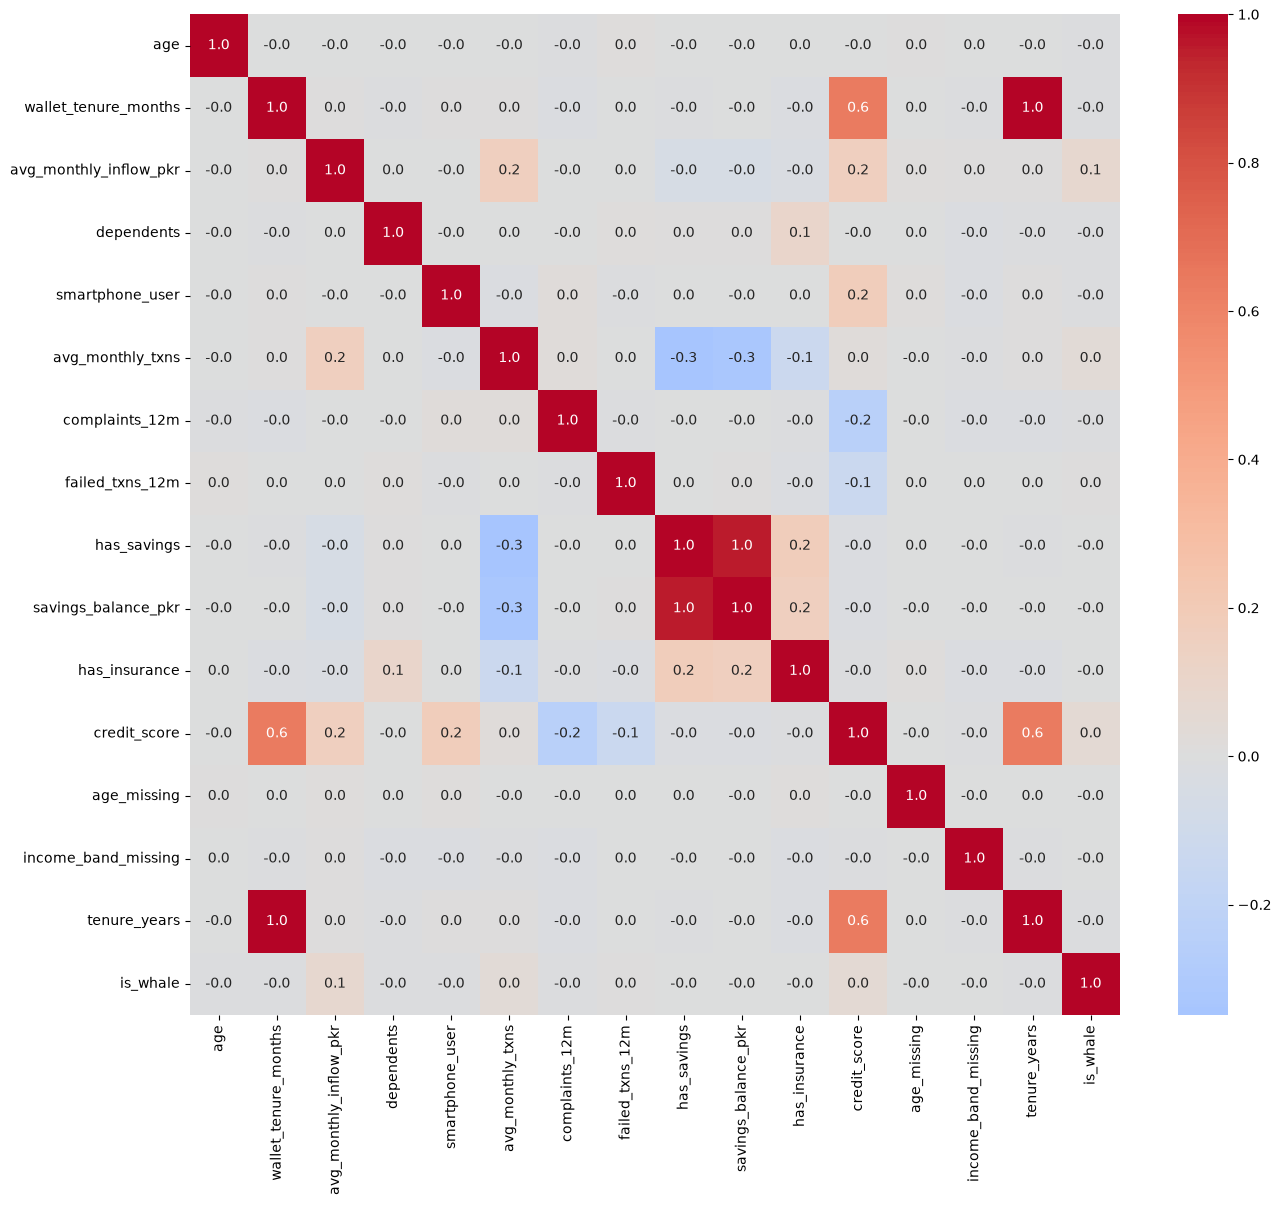

In [194]:
corr = train_cust.corr(method="spearman", numeric_only=True)

plt.figure(figsize=(15, 13))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", center=0)
plt.show() 

In [195]:
for c in train_cust.select_dtypes(["category","object"]).drop(columns=["customer_id","churned_12m"]):
    print(f"\n=== {c} ===")
    print(pd.crosstab(train_cust[c], train_cust["churned_12m"], normalize="index").round(3))
    print("n per group:", train_cust[c].value_counts().to_dict())

C:\Program Files\KMSpico\temp\ipykernel_11628\2713005037.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in train_cust.select_dtypes(["category","object"]).drop(columns=["customer_id","churned_12m"]):



=== region ===
churned_12m      N      Y
region                   
AJK-GB       0.918  0.082
Balochistan  0.937  0.063
Islamabad    0.928  0.072
KP           0.928  0.072
Punjab       0.918  0.082
Sindh        0.924  0.076
n per group: {'Punjab': 5061, 'Sindh': 2770, 'KP': 1705, 'Islamabad': 1248, 'Balochistan': 614, 'AJK-GB': 602}

=== city ===
churned_12m       N      Y
city                      
Abbottabad    0.913  0.087
Faisalabad    0.911  0.089
Gilgit        0.903  0.097
Gwadar        0.954  0.046
Hyderabad     0.917  0.083
Islamabad     0.928  0.072
Karachi       0.922  0.078
Lahore        0.918  0.082
Mardan        0.954  0.046
Multan        0.914  0.086
Muzaffarabad  0.937  0.063
Peshawar      0.918  0.082
Quetta        0.919  0.081
Rawalpindi    0.925  0.075
Sargodha      0.923  0.077
Sukkur        0.934  0.066
n per group: {'Islamabad': 1248, 'Lahore': 1031, 'Sargodha': 1027, 'Faisalabad': 1024, 'Multan': 1005, 'Rawalpindi': 974, 'Karachi': 944, 'Hyderabad': 923, 'Sukkur':

In [196]:
# Needs bins:

# inflow_to_loan_ratio (H1) — qcut, no meaningful boundaries
# wallet_tenure_months (H3) — cut, years are natural
# age (E1) — cut, age bands are natural
# avg_monthly_inflow_pkr (E5) — qcut, skewed money
# credit_score (H2) — optional; the t-test doesn't need bins, but a rate table by score band reads better

# Counts — bin, but with cut and meaningful edges:

# complaints_12m (H5) — 0 / 1 / 2+
# failed_txns_12m (H6) — 0 / 1 / 2+
# active_months (H7) — 12 vs <12, given the variance problem

# No bins — already categorical:

# region, purpose, segment_true, declared_income_band
# has_savings, has_insurance (H8) — already 0/1

# The rule you already have: qcut when no boundary is meaningful, cut when one is.

In [197]:
train_cust.sample(5)

,customer_id,age,region,city,segment_true,onboarding_date,wallet_tenure_months,declared_income_band,avg_monthly_inflow_pkr,dependents,...,failed_txns_12m,has_savings,savings_balance_pkr,has_insurance,credit_score,churned_12m,age_missing,income_band_missing,tenure_years,is_whale
12681,C112681,31.0,KP,Mardan,payroll,2019-05-22,74.0,25-50k,44400.0,4,...,1,0,0.0,1,526,N,0,0,6.17,0
13754,C113754,53.0,Punjab,Faisalabad,payroll,2023-10-17,19.0,25-50k,34200.0,1,...,2,0,0.0,0,402,N,0,0,1.58,0
5155,C105155,36.0,KP,Mardan,saver,2023-12-08,18.0,25-50k,33000.0,2,...,0,1,20200.0,1,440,N,0,0,1.50,0
11932,C111932,20.0,Sindh,Hyderabad,merchant,2023-10-22,20.0,25-50k,36700.0,2,...,0,0,0.0,1,431,N,0,0,1.67,0
4111,C104111,18.0,KP,Mardan,payroll,2018-02-28,88.0,25-50k,54300.0,0,...,2,0,0.0,0,550,N,0,0,7.33,0


In [198]:
train_cust["churn"]=train_cust["churned_12m"].map({"Y":1, "N": 0})

In [199]:

cols_band=["avg_monthly_inflow_pkr","credit_score"]

for band in cols_band:
    ans=train_cust.groupby(pd.qcut(train_cust[band],5))["churn"].agg(["mean","size"])
    print(ans)

                            mean  size
avg_monthly_inflow_pkr                
(7999.999, 18900.0]     0.086555  2421
(18900.0, 27300.0]      0.077993  2413
(27300.0, 36900.0]      0.076857  2384
(36900.0, 53020.0]      0.079161  2382
(53020.0, 343700.0]     0.064405  2400
                      mean  size
credit_score                    
(312.999, 431.0]  0.118637  2410
(431.0, 455.0]    0.095159  2455
(455.0, 477.0]    0.067782  2378
(477.0, 506.0]    0.066494  2368
(506.0, 656.0]    0.035897  2389


In [200]:
cols_bands=["age","wallet_tenure_months","complaints_12m","failed_txns_12m","dependents"]

for band in cols_bands:
    ans=train_cust[band].value_counts(normalize=True)
    print(ans)

age
18.0    0.059500
33.0    0.055917
31.0    0.043667
30.0    0.043417
34.0    0.043167
32.0    0.042167
35.0    0.042167
37.0    0.041750
36.0    0.040417
28.0    0.039583
29.0    0.039333
27.0    0.037750
38.0    0.035167
39.0    0.034333
26.0    0.032833
40.0    0.030583
25.0    0.029167
24.0    0.027667
41.0    0.027167
23.0    0.026083
42.0    0.025667
43.0    0.022417
22.0    0.020333
21.0    0.020333
44.0    0.018833
20.0    0.016917
45.0    0.016000
46.0    0.015500
47.0    0.013167
19.0    0.012833
48.0    0.010333
49.0    0.009500
50.0    0.006250
51.0    0.005333
52.0    0.003917
53.0    0.002833
54.0    0.002333
55.0    0.001917
56.0    0.001667
59.0    0.000833
62.0    0.000417
60.0    0.000250
58.0    0.000250
64.0    0.000083
57.0    0.000083
61.0    0.000083
66.0    0.000083
Name: proportion, dtype: float64
wallet_tenure_months
13.0    0.093333
14.0    0.053167
17.0    0.044250
18.0    0.041333
15.0    0.041083
          ...   
84.0    0.000583
90.0    0.000500
85.0   

In [201]:
pd.qcut(train_cust["age"], 4)

0          (27.0, 33.0]
2          (38.0, 66.0]
3        (17.999, 27.0]
6          (27.0, 33.0]
7        (17.999, 27.0]
              ...      
14994    (17.999, 27.0]
14995      (38.0, 66.0]
14996      (38.0, 66.0]
14998      (33.0, 38.0]
14999      (27.0, 33.0]
Name: age, Length: 12000, dtype: category
Categories (4, interval[float64, right]): [(17.999, 27.0] < (27.0, 33.0] < (33.0, 38.0] < (38.0, 66.0]]

In [202]:
#pd.cut(series, bins=[-1, 0, 1, 100], labels=["0", "1", "2+"])

train_cust.groupby(pd.cut(train_cust["age"], bins=[17,29,40,66],labels=["17-29","30-40","41-66"]))["churn"].agg(["mean","size"])

,mean,size
age,,
17-29,0.084329,4348
30-40,0.076403,5433
41-66,0.064233,2219


In [203]:
train_cust.groupby(pd.qcut(train_cust["age"],4))["churn"].agg(["mean","size"])

,mean,size
age,,
"(17.999, 27.0]",0.083657,3401
"(27.0, 33.0]",0.083602,3169
"(33.0, 38.0]",0.067058,2432
"(38.0, 66.0]",0.070673,2998


In [204]:
train_cust.groupby(pd.qcut(train_cust["wallet_tenure_months"],4))["churn"].agg(["mean","size"])

,mean,size
wallet_tenure_months,,
"(8.999, 17.0]",0.117297,3418
"(17.0, 24.0]",0.091967,2818
"(24.0, 35.0]",0.065712,2781
"(35.0, 96.0]",0.027341,2983


In [205]:
train_cust.groupby(pd.qcut(train_cust["credit_score"],4))["churn"].agg(["mean","size"])

,mean,size
credit_score,,
"(312.999, 438.0]",0.115807,3054
"(438.0, 466.0]",0.080917,3031
"(466.0, 497.0]",0.067506,2922
"(497.0, 656.0]",0.042662,2993


In [206]:
tenure_bins = pd.qcut(train_cust["wallet_tenure_months"], 4)
score_bins  = pd.qcut(train_cust["credit_score"], 4)

In [207]:
train_cust.groupby([tenure_bins, score_bins])["churn"].mean().unstack()

credit_score,"(312.999, 438.0]","(438.0, 466.0]","(466.0, 497.0]","(497.0, 656.0]"
wallet_tenure_months,,,,
"(8.999, 17.0]",0.132110,0.099704,0.099828,0.146154
"(17.0, 24.0]",0.109195,0.077249,0.088663,0.096774
"(24.0, 35.0]",0.083333,0.070667,0.059072,0.057239
"(35.0, 96.0]",0.014706,0.050388,0.028037,0.024515


In [208]:
from scipy.stats import chi2_contingency

table=pd.crosstab(tenure_bins,train_cust["churn"])
chi2, p , dof, expected= chi2_contingency(table)
print(p)

2.5778409972713335e-41


In [209]:
#"complaints_12m","failed_txns_12m","dependents"
comp_bins = train_cust.groupby(pd.cut(train_cust["complaints_12m"],
                   bins=[-1, 0, 1, 10],
                   labels=["0", "1", "2+"]))["churn"].agg(["mean","size"])
print(comp_bins)

fail_bins = train_cust.groupby(pd.cut(train_cust["failed_txns_12m"],
                   bins=[-1, 0, 1, 2, 10],
                   labels=["0", "1", "2", "3+"]))["churn"].agg(["mean","size"])
print(fail_bins)
dep_bins  = train_cust.groupby(pd.cut(train_cust["dependents"],
                   bins=[-1, 0, 2, 10],
                   labels=["0", "1-2", "3+"]))["churn"].agg(["mean","size"])
print(dep_bins) 

                    mean  size
complaints_12m                
0               0.057125  6504
1               0.090041  3949
2+              0.127646  1547
                     mean  size
failed_txns_12m                
0                0.068429  3953
1                0.073204  4423
2                0.094340  2427
3+               0.084399  1197
                mean  size
dependents                
0           0.070392  2397
1-2         0.077750  7018
3+          0.081262  2585


In [210]:
comp_binn = pd.cut(train_cust["complaints_12m"],
                   bins=[-1, 0, 1, 10],
                   labels=["0", "1", "2+"])

In [278]:
table= pd.crosstab(comp_binn,train_cust["churn"])
print(table)

chi2, p ,dof, expected= chi2_contingency(table)
print("p= ",p)

churn            0.0  1.0
complaints_12m           
0               6008  364
1               3527  349
2+              1319  193
p=  2.860974485676645e-22


In [211]:
train_cust.groupby([tenure_bins, comp_binn])["churn"].mean().unstack()

complaints_12m,0,1,2+
wallet_tenure_months,,,
"(8.999, 17.0]",0.083744,0.141798,0.194260
"(17.0, 24.0]",0.069416,0.106383,0.146067
"(24.0, 35.0]",0.050894,0.079383,0.090909
"(35.0, 96.0]",0.022005,0.025263,0.058824


In [212]:
cats=["smartphone_user", "has_savings", "has_insurance", "is_whale", "age_missing", "income_band_missing"]

for cal in cats:
    final=train_cust.groupby(cal)["churn"].agg(["mean","size"])
    print(final)

                     mean  size
smartphone_user                
0                0.070229  2010
1                0.078407  9990
                 mean  size
has_savings                
0            0.061401  6969
1            0.098663  5031
                  mean  size
has_insurance               
0              0.07136  9515
1              0.09873  2485
              mean   size
is_whale                 
0         0.077002  11978
1         0.100000     22
                 mean   size
age_missing                 
0            0.077042  11869
1            0.076923    131
                         mean   size
income_band_missing                 
0                    0.077882  10566
1                    0.070872   1434


In [213]:
train_cust.columns

Index(['customer_id', 'age', 'region', 'city', 'segment_true',
       'onboarding_date', 'wallet_tenure_months', 'declared_income_band',
       'avg_monthly_inflow_pkr', 'dependents', 'smartphone_user',
       'avg_monthly_txns', 'complaints_12m', 'failed_txns_12m', 'has_savings',
       'savings_balance_pkr', 'has_insurance', 'credit_score', 'churned_12m',
       'age_missing', 'income_band_missing', 'tenure_years', 'is_whale',
       'churn'],
      dtype='str')

In [214]:
train_cust.groupby(pd.qcut(train_cust["avg_monthly_txns"], 4))["churn"].agg(["mean", "size"])

,mean,size
avg_monthly_txns,,
"(2.499, 9.7]",0.103992,3036
"(9.7, 13.4]",0.093897,3033
"(13.4, 21.1]",0.072917,2939
"(21.1, 147.6]",0.036339,2992


In [279]:
table1= pd.crosstab(train_cust["has_savings"],train_cust["has_insurance"])
print(table1)

chi2, p ,dof, expected= chi2_contingency(table1)
print("p= ",p)

has_insurance     0     1
has_savings              
0              5946  1023
1              3569  1462
p=  8.001976630668883e-82


In [280]:
table2= pd.crosstab(dep_bins,train_cust["has_insurance"])
print(table2)

chi2, p ,dof, expected= chi2_contingency(table2)
print("p= ",p)

has_insurance     0     1
dependents               
0              2019   378
1-2            5600  1418
3+             1896   689
p=  8.904600302466201e-21


In [215]:
activity_bins=pd.qcut(train_cust["avg_monthly_txns"], 4)

In [216]:
train_cust.groupby([tenure_bins, activity_bins])["churn"].mean().unstack()

avg_monthly_txns,"(2.499, 9.7]","(9.7, 13.4]","(13.4, 21.1]","(21.1, 147.6]"
wallet_tenure_months,,,,
"(8.999, 17.0]",0.172111,0.133406,0.104809,0.059036
"(17.0, 24.0]",0.119565,0.128637,0.078402,0.040816
"(24.0, 35.0]",0.077381,0.077446,0.070015,0.036419
"(35.0, 96.0]",0.042471,0.023845,0.035326,0.006739


In [217]:
train_cust.groupby(tenure_bins)["avg_monthly_inflow_pkr"].agg(["median", "size"])

,median,size
wallet_tenure_months,,
"(8.999, 17.0]",31600.0,3418
"(17.0, 24.0]",31600.0,2818
"(24.0, 35.0]",31600.0,2781
"(35.0, 96.0]",32200.0,2983


In [218]:
train_cust.groupby(activity_bins)["avg_monthly_inflow_pkr"].agg(["median", "size"])

,median,size
avg_monthly_txns,,
"(2.499, 9.7]",29900.0,3036
"(9.7, 13.4]",29500.0,3033
"(13.4, 21.1]",30200.0,2939
"(21.1, 147.6]",38800.0,2992


In [219]:
act_bins = pd.qcut(train_cust["avg_monthly_txns"], 4)

# who is in each activity band?
print(pd.crosstab(act_bins, train_cust["segment_true"], normalize="index").round(3))

# and what each segment looks like on all three measures
print(train_cust.groupby("segment_true").agg(
    churn        = ("churn", "mean"),
    median_inflow= ("avg_monthly_inflow_pkr", "median"),
    median_txns  = ("avg_monthly_txns", "median"),
    n            = ("churn", "size"),
))

segment_true      borrower  merchant  payroll  saver
avg_monthly_txns                                    
(2.499, 9.7]         0.222     0.000    0.199  0.579
(9.7, 13.4]          0.285     0.000    0.431  0.284
(13.4, 21.1]         0.251     0.009    0.611  0.128
(21.1, 147.6]        0.044     0.799    0.148  0.008
                 churn  median_inflow  median_txns     n
segment_true                                            
borrower      0.078059        30600.0        12.00  2412
merchant      0.029762        42100.0        46.95  2416
payroll       0.071762        29600.0        13.90  4150
saver         0.120916        29700.0         9.00  3022


In [220]:
train_cust.groupby([train_cust["segment_true"], act_bins])["churn"].agg(["mean","size"]).unstack()

mean                                         \
avg_monthly_txns (2.499, 9.7] (9.7, 13.4] (13.4, 21.1] (21.1, 147.6]   
segment_true                                                           
borrower             0.080060    0.077103     0.081944      0.053030   
merchant                  NaN         NaN     0.000000      0.030082   
payroll              0.065878    0.086719     0.065760      0.060046   
saver                0.126230    0.121749     0.094340      0.120000   

                         size                                         
avg_monthly_txns (2.499, 9.7] (9.7, 13.4] (13.4, 21.1] (21.1, 147.6]  
segment_true                                                          
borrower                675.0       865.0        739.0         133.0  
merchant                  NaN         NaN         26.0        2390.0  
payroll                 603.0      1306.0       1797.0         444.0  
saver                  1758.0       862.0        377.0          25.0

In [221]:
loans_train["defaulted"].unique()

array([0, 1], dtype=int8)

In [222]:
#loans_train["default_num"] = loans_train["defaulted"].map({"True": 1, "False": 0})

LOANS

In [223]:
cats_loan=["purpose", "term_months", "amount_suspect"]

for cals in cats_loan:
    final_cat=loans_train.groupby(cals)["defaulted"].agg(["mean","size"])
    print(final_cat)

                      mean  size
purpose                         
device_finance    0.132209  1127
emergency         0.123258   933
merchant_advance  0.283241  1444
nano_loan         0.079585  2890
                 mean  size
term_months                
1            0.142537  2231
3            0.140306  1960
6            0.136364  1606
12           0.152429   597
                    mean  size
amount_suspect                
False           0.141226  6394


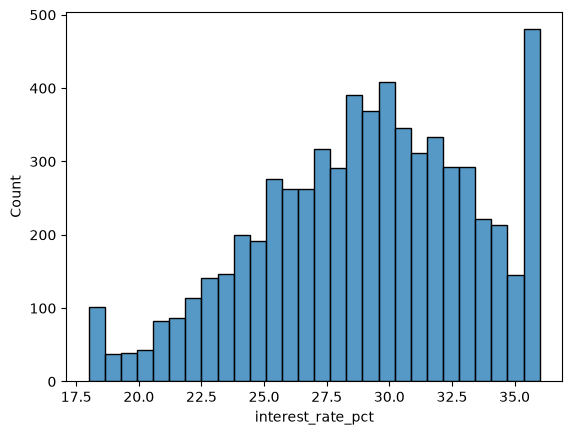

In [224]:
sns.histplot(data=loans_train,x="interest_rate_pct")
plt.show()

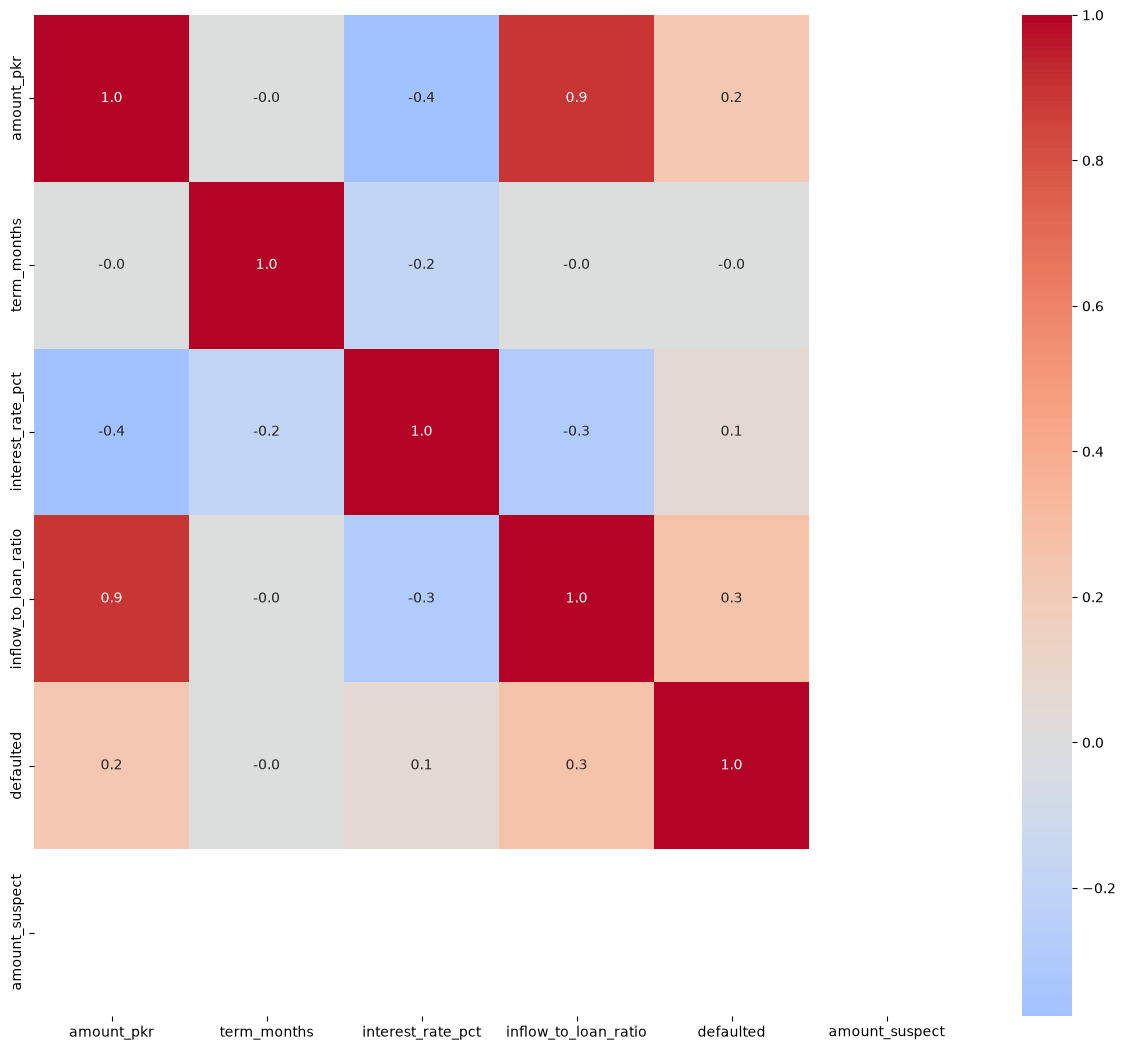

In [225]:
corr = loans_train.corr(method="spearman", numeric_only=True)

plt.figure(figsize=(15, 13))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", center=0)
plt.show() 

In [227]:
continous=["amount_pkr", "inflow_to_loan_ratio", "interest_rate_pct"]

for con in continous:
    co=loans_train.groupby(pd.qcut(loans_train[con],5),observed=True)["defaulted"].agg(["mean","size"])
    print(co)

                          mean  size
amount_pkr                          
(1999.999, 10857.6]   0.065676  1279
(10857.6, 19328.6]    0.084441  1279
(19328.6, 37501.0]    0.104851  1278
(37501.0, 106474.6]   0.139953  1279
(106474.6, 399599.0]  0.311181  1279
                                  mean  size
inflow_to_loan_ratio                        
(0.009000000000000001, 0.29]  0.066116  1331
(0.29, 0.59]                  0.077607  1237
(0.59, 1.24]                  0.085625  1273
(1.24, 3.49]                  0.133125  1277
(3.49, 49.05]                 0.344828  1276
                       mean  size
interest_rate_pct                
(17.999, 25.3]     0.094543  1301
(25.3, 28.2]       0.149612  1290
(28.2, 30.4]       0.149497  1291
(30.4, 32.9]       0.169316  1258
(32.9, 36.0]       0.144338  1254


In [228]:
loans_train.groupby(loans_train["disbursed_date"].dt.to_period("M"))["defaulted"].agg(["mean","size"])

,mean,size
disbursed_date,,
2024-07,0.130068,592
2024-08,0.135417,576
2024-09,0.112546,542
2024-10,0.166954,581
2024-11,0.150338,592
2024-12,0.159016,610
2025-01,0.144366,568
2025-02,0.156934,548
2025-03,0.141553,657


TRANSACTIONS

            total_txns  total_value   rows
month                                     
2024-07-01       75084  169009290.0  11258
2024-08-01       73382  166517630.0  10991
2024-09-01       72379  162326570.0  10825
2024-10-01       71324  160695580.0  10622
2024-11-01       69473  157536510.0  10405
2024-12-01       68516  156478330.0  10261
2025-01-01       67977  154872010.0  10073
2025-02-01       67169  150794100.0   9936
2025-03-01       65152  147151170.0   9767
2025-04-01       94457  310871490.0   9653
2025-05-01       64689  145971150.0   9496
2025-06-01       83373  241859760.0   9473


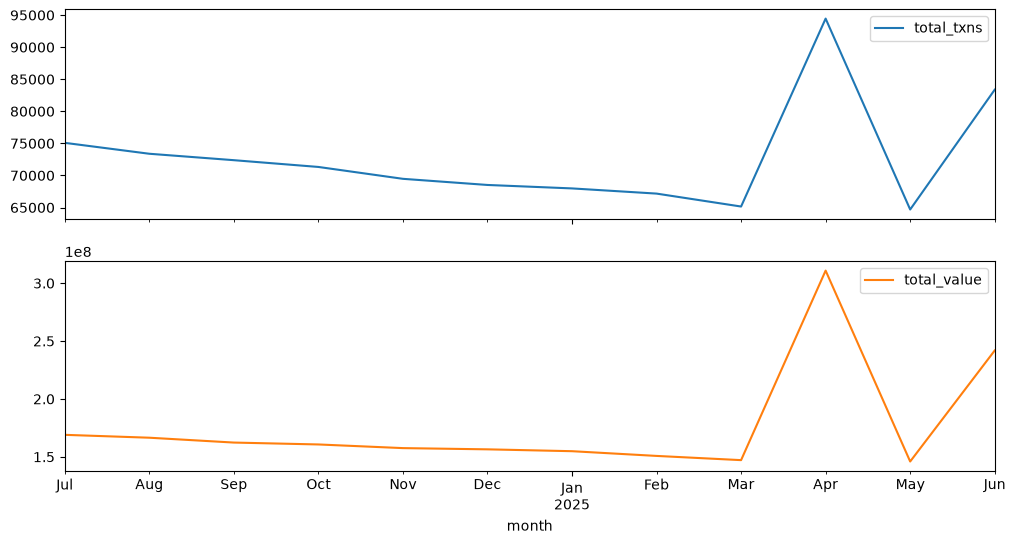

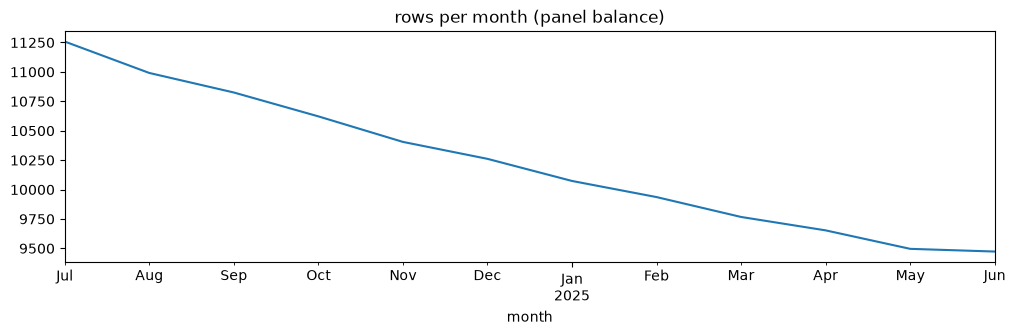

               txn_count  txn_value_pkr
txn_count       1.000000       0.861123
txn_value_pkr   0.861123       1.000000
count    119487.000000
mean       2393.131963
std        1321.722529
min         205.000000
25%        1482.500000
50%        2093.750000
75%        2965.000000
max       39118.181818
dtype: float64


In [229]:
# 1 — is H9 still intact?
per_month = txns_train.groupby("month").agg(
    total_txns  = ("txn_count", "sum"),
    total_value = ("txn_value_pkr", "sum"),
    rows        = ("customer_id", "size"),
)
print(per_month)
per_month[["total_txns", "total_value"]].plot(subplots=True, figsize=(12,6))
plt.show()


# 2 — is the panel still balanced?
per_month["rows"].plot(figsize=(12,3), title="rows per month (panel balance)")
plt.show()


# 3 — does value behave like count?
print(txns_train[["txn_count","txn_value_pkr"]].corr(method="spearman"))
print(txns_train["txn_value_pkr"].div(txns_train["txn_count"]).describe())

            txns_per_customer  value_per_customer
month                                            
2024-07-01                6.7             15012.4
2024-08-01                6.7             15150.4
2024-09-01                6.7             14995.5
2024-10-01                6.7             15128.6
2024-11-01                6.7             15140.5
2024-12-01                6.7             15249.8
2025-01-01                6.7             15375.0
2025-02-01                6.8             15176.5
2025-03-01                6.7             15066.2
2025-04-01                9.8             32204.7
2025-05-01                6.8             15371.9
2025-06-01                8.8             25531.5


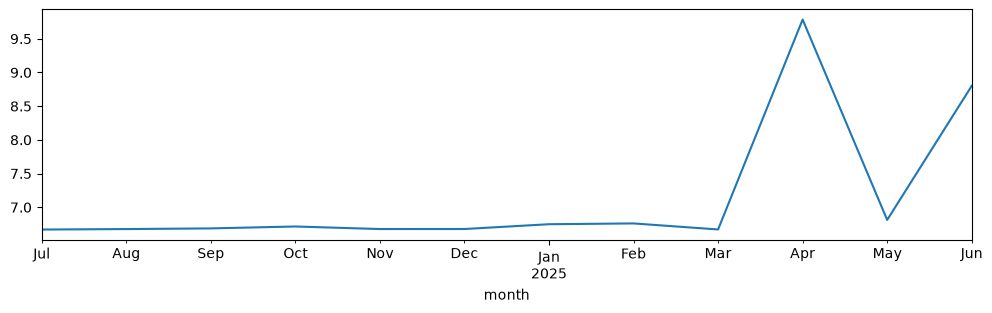

In [230]:
per_month["txns_per_customer"] = per_month["total_txns"] / per_month["rows"]
per_month["value_per_customer"] = per_month["total_value"] / per_month["rows"]
print(per_month[["txns_per_customer", "value_per_customer"]].round(1))
per_month["txns_per_customer"].plot(figsize=(12,3))
plt.show()

In [231]:
train_cust.groupby("has_savings")["has_insurance"].agg(["mean","size"]) 

,mean,size
has_savings,,
0,0.146793,6969
1,0.290598,5031


In [232]:
train_cust.groupby(pd.cut(train_cust["dependents"], [-1,0,2,10], labels=["0","1-2","3+"]),
                   observed=True)["has_insurance"].agg(["mean","size"])

,mean,size
dependents,,
0,0.157697,2397
1-2,0.202052,7018
3+,0.266538,2585


In [233]:
dep_bins = pd.cut(train_cust["dependents"], [-1,0,2,10], labels=["0","1-2","3+"])
train_cust.groupby(["has_savings", dep_bins], observed=True)["has_insurance"].mean().unstack()

dependents,0,1-2,3+
has_savings,,,
0,0.104255,0.139690,0.20600
1,0.234043,0.287597,0.35023


MERGE

In [238]:
#transactions

txn_summary= txns_train.groupby("customer_id").agg(
    total_txns= ("txn_count","sum"),
    total_value   = ("txn_value_pkr", "sum"),
    avg_txns_computed = ("txn_count", lambda s: s.sum() / 12),
    active_months = ("txn_count", lambda s: (s>0).sum()),
).reset_index()

In [239]:
train_cust1=pd.read_parquet(CUSTOMERS_TRAIN)
train_cust1=train_cust1.merge(txn_summary,on="customer_id",how="left")
train_cust1

,customer_id,age,region,city,segment_true,onboarding_date,wallet_tenure_months,declared_income_band,avg_monthly_inflow_pkr,dependents,...,credit_score,churned_12m,age_missing,income_band_missing,tenure_years,is_whale,total_txns,total_value,avg_txns_computed,active_months
0,C100000,33.0,Sindh,Karachi,payroll,2024-05-14,13.0,25-50k,31700.0,1,...,442,N,0,0,1.08,0,34,60460.0,2.833333,7
1,C100002,41.0,KP,Peshawar,borrower,2024-05-08,13.0,25-50k,41000.0,1,...,426,N,0,0,1.08,0,33,78460.0,2.750000,11
2,C100003,23.0,Punjab,Lahore,payroll,2024-04-10,15.0,25-50k,15800.0,1,...,399,N,0,1,1.25,0,80,159680.0,6.666667,6
3,C100006,32.0,Punjab,Multan,borrower,2023-10-03,21.0,50-100k,45500.0,2,...,489,N,0,0,1.75,0,49,103940.0,4.083333,9
4,C100007,25.0,Balochistan,Quetta,saver,2024-01-17,17.0,50-100k,48900.0,1,...,451,N,0,0,1.42,0,29,116010.0,2.416667,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,C114994,26.0,Punjab,Multan,saver,2023-09-27,21.0,<25k,25600.0,0,...,499,N,0,0,1.75,0,40,77910.0,3.333333,11
11996,C114995,44.0,Punjab,Sargodha,saver,2024-02-19,15.0,25-50k,24500.0,2,...,460,N,0,0,1.25,0,23,45830.0,1.916667,11
11997,C114996,43.0,Punjab,Multan,payroll,2020-10-02,57.0,<25k,19700.0,2,...,525,N,0,0,4.75,0,26,65280.0,2.166667,7
11998,C114998,34.0,Sindh,Sukkur,payroll,2024-05-16,13.0,25-50k,37400.0,0,...,370,N,0,0,1.08,0,58,114010.0,4.833333,12


In [237]:
train_cust1["total_txns"].isna().sum()

np.int64(0)

In [243]:
train_cust1["churn"]=train_cust1["churned_12m"].map({"Y":1, "N": 0})

In [244]:
train_cust1.groupby(pd.qcut(train_cust1["avg_txns_computed"],4),observed=True)["churn"].agg(["mean","size"])

,mean,size
avg_txns_computed,,
"(0.249, 2.75]",0.169256,3078
"(2.75, 4.083]",0.069963,3023
"(4.083, 6.667]",0.042516,2953
"(6.667, 50.75]",0.021959,2946


In [245]:
train_cust1.groupby(["segment_true", pd.qcut(train_cust1["avg_txns_computed"], 4)],
                    observed=True)["churn"].mean().unstack() 

avg_txns_computed,"(0.249, 2.75]","(2.75, 4.083]","(4.083, 6.667]","(6.667, 50.75]"
segment_true,,,,
borrower,0.147383,0.075325,0.026243,0.006667
merchant,0.000000,0.076923,0.145455,0.023810
payroll,0.167358,0.074862,0.041949,0.017544
saver,0.180547,0.058632,0.045662,0.027027


In [246]:
train_cust1.groupby(pd.cut(train_cust1["active_months"], [-1, 6, 9, 11, 12]),
                    observed=True)["churn"].agg(["mean","size"])

,mean,size
active_months,,
"(-1, 6]",0.341703,933
"(6, 9]",0.139667,3047
"(9, 11]",0.032993,4793
"(11, 12]",0.006039,3227


In [247]:
loans_train1 = loans[loans["customer_id"].isin(train_ids)]
loans_train1= loans_train1.merge(train_cust, on="customer_id", how="left")
loans_train1

,loan_id,customer_id,disbursed_date,purpose,amount_pkr,term_months,interest_rate_pct,inflow_to_loan_ratio,defaulted,amount_suspect,...,has_savings,savings_balance_pkr,has_insurance,credit_score,churned_12m,age_missing,income_band_missing,tenure_years,is_whale,churn
0,L500003,C112525,2024-08-15,nano_loan,12857.0,3,33.3,0.48,0,False,...,0,0.0,0,444,N,0,0,1.75,0,0.0
1,L500004,C104772,2024-10-22,nano_loan,22631.0,3,29.4,0.75,0,False,...,0,0.0,0,465,N,0,0,1.75,0,0.0
2,L500005,C111618,2025-02-25,merchant_advance,158361.0,1,33.6,6.09,1,False,...,0,0.0,0,421,N,0,1,1.58,0,0.0
3,L500006,C102207,2025-01-13,nano_loan,21081.0,6,31.4,1.33,0,False,...,0,0.0,1,471,N,0,0,3.17,0,0.0
4,L500007,C100980,2025-02-12,nano_loan,11358.0,3,34.3,0.26,1,False,...,0,0.0,1,416,N,0,0,1.17,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6389,L507994,C108628,2024-08-05,nano_loan,17440.0,1,30.4,0.45,0,False,...,1,63900.0,0,483,N,0,0,2.92,0,0.0
6390,L507995,C105831,2025-05-26,device_finance,82169.0,1,29.9,2.79,0,False,...,0,0.0,0,426,N,0,0,2.17,0,0.0
6391,L507996,C110319,2025-01-12,merchant_advance,134329.0,1,32.9,5.46,0,False,...,0,0.0,0,428,N,0,0,1.83,0,0.0
6392,L507997,C103624,2024-12-31,nano_loan,24820.0,3,28.3,0.91,0,False,...,1,27000.0,0,511,N,0,0,3.75,0,0.0


In [249]:
loans_train1.groupby("region")["defaulted"].agg(["mean","size"])

,mean,size
region,,
AJK-GB,0.103858,337
Balochistan,0.197368,304
Islamabad,0.130499,682
KP,0.133621,928
Punjab,0.138163,2678
Sindh,0.153584,1465


In [252]:
loans_train1.groupby(["region","purpose"])["defaulted"].agg(["mean","size"]).unstack()

mean                                       \
purpose     device_finance emergency merchant_advance nano_loan   
region                                                            
AJK-GB            0.074074  0.018868         0.236842  0.077922   
Balochistan       0.195652  0.180000         0.386667  0.097744   
Islamabad         0.112782  0.136842         0.248276  0.080906   
KP                0.097701  0.139706         0.283654  0.070732   
Punjab            0.145228  0.119681         0.266667  0.077869   
Sindh             0.142857  0.125561         0.314706  0.084337   

                      size                                       
purpose     device_finance emergency merchant_advance nano_loan  
region                                                           
AJK-GB                  54        53               76       154  
Balochistan             46        50               75       133  
Islamabad              133        95              145       309  
KP                     174       136              208       410  
Punjab                 482       376              600      1220  
Sindh                  238       223              340       664

In [253]:
regions=loans_train1["region"]=="Balochistan"

table= pd.crosstab(regions,loans_train1["defaulted"])
print(table)

chi2, p ,dof, expected= chi2_contingency(table)
print("p= ",p)
print(expected)

defaulted     0    1
region              
False      5247  843
True        244   60
p=  0.005178354247423724
[[5229.93274945  860.06725055]
 [ 261.06725055   42.93274945]]


In [269]:
loans_train1.groupby(pd.qcut(loans_train1["credit_score"],4),observed=True)["defaulted"].agg(["mean","size"])

,mean,size
credit_score,,
"(323.999, 438.0]",0.218964,1603
"(438.0, 466.0]",0.165432,1620
"(466.0, 499.0]",0.120025,1608
"(499.0, 632.0]",0.058221,1563


In [270]:
loans_train1.groupby(pd.qcut(loans_train1["wallet_tenure_months"],4),observed=True)["defaulted"].agg(["mean","size"])

,mean,size
wallet_tenure_months,,
"(8.999, 17.0]",0.220988,1801
"(17.0, 24.0]",0.153398,1545
"(24.0, 36.0]",0.119110,1528
"(36.0, 96.0]",0.056579,1520


In [271]:
cre=pd.qcut(loans_train1["credit_score"],4)
ten=pd.qcut(loans_train1["wallet_tenure_months"],4) 

In [272]:
loans_train1.groupby([cre,ten])["defaulted"].agg(["mean","size"]).unstack()

mean                                         \
wallet_tenure_months (8.999, 17.0] (17.0, 24.0] (24.0, 36.0] (36.0, 96.0]   
credit_score                                                                
(323.999, 438.0]          0.252887     0.194215     0.151376     0.142857   
(438.0, 466.0]            0.219780     0.145558     0.131265     0.126984   
(466.0, 499.0]            0.160883     0.138889     0.118919     0.061765   
(499.0, 632.0]            0.111111     0.080882     0.083333     0.043180   

                              size                                         
wallet_tenure_months (8.999, 17.0] (17.0, 24.0] (24.0, 36.0] (36.0, 96.0]  
credit_score                                                               
(323.999, 438.0]               866          484          218           35  
(438.0, 466.0]                 546          529          419          126  
(466.0, 499.0]                 317          396          555          340  
(499.0, 632.0]                  72          136          336         1019

In [273]:
table= pd.crosstab(cre,loans_train1["defaulted"])
print(table)

chi2, p ,dof, expected= chi2_contingency(table)
print("p= ",p)

defaulted            0    1
credit_score               
(323.999, 438.0]  1252  351
(438.0, 466.0]    1352  268
(466.0, 499.0]    1415  193
(499.0, 632.0]    1472   91
p=  2.605353412549995e-39


In [274]:
table= pd.crosstab(ten,loans_train1["defaulted"])
print(table)

chi2, p ,dof, expected= chi2_contingency(table)
print("p= ",p)

defaulted                0    1
wallet_tenure_months           
(8.999, 17.0]         1403  398
(17.0, 24.0]          1308  237
(24.0, 36.0]          1346  182
(36.0, 96.0]          1434   86
p=  1.9213802646700676e-41


In [275]:
rat = pd.qcut(loans_train1["inflow_to_loan_ratio"], 5)
loans_train1.groupby([loans_train1["purpose"], rat], observed=True)["defaulted"].agg(["mean","size"]).unstack()

mean                            \
inflow_to_loan_ratio (0.009000000000000001, 0.29] (0.29, 0.59] (0.59, 1.24]   
purpose                                                                       
device_finance                           0.086957     0.011765     0.055794   
emergency                                0.078571     0.105263     0.104478   
merchant_advance                         0.000000     0.153846     0.049383   
nano_loan                                0.064267     0.076344     0.091346   

                                                                        size  \
inflow_to_loan_ratio (1.24, 3.49] (3.49, 49.05] (0.009000000000000001, 0.29]   
purpose                                                                        
device_finance           0.107750      0.295720                         23.0   
emergency                0.177778      0.291667                        140.0   
merchant_advance         0.129944      0.358794                          1.0   
nano_loan                0.159763           NaN                       1167.0   

                                                                           
inflow_to_loan_ratio (0.29, 0.59] (0.59, 1.24] (1.24, 3.49] (3.49, 49.05]  
purpose                                                                    
device_finance               85.0        233.0        529.0         257.0  
emergency                   209.0        335.0        225.0          24.0  
merchant_advance             13.0         81.0        354.0         995.0  
nano_loan                   930.0        624.0        169.0           NaN

In [276]:
table= pd.crosstab(rat,loans_train1["defaulted"])
print(table)

chi2, p ,dof, expected= chi2_contingency(table)
print("p= ",p)

defaulted                        0    1
inflow_to_loan_ratio                   
(0.009000000000000001, 0.29]  1243   88
(0.29, 0.59]                  1141   96
(0.59, 1.24]                  1164  109
(1.24, 3.49]                  1107  170
(3.49, 49.05]                  836  440
p=  1.407592028849071e-122


In [277]:
table= pd.crosstab(loans_train1["purpose"],loans_train1["defaulted"])
print(table)

chi2, p ,dof, expected= chi2_contingency(table)
print("p= ",p)

defaulted            0    1
purpose                    
device_finance     978  149
emergency          818  115
merchant_advance  1035  409
nano_loan         2660  230
p=  4.549116085871566e-72


In [281]:
# E5 — does absolute inflow predict default?
inf = pd.qcut(loans_train1["avg_monthly_inflow_pkr"], 5)
loans_train1.groupby(inf, observed=True)["defaulted"].agg(["mean","size"])

,mean,size
avg_monthly_inflow_pkr,,
"(7999.999, 19600.0]",0.241272,1289
"(19600.0, 28200.0]",0.142745,1275
"(28200.0, 38300.0]",0.132134,1279
"(38300.0, 55700.0]",0.100471,1274
"(55700.0, 343700.0]",0.088489,1277


In [282]:
# E3 — does the ratio effect differ by segment?
loans_train1.groupby([loans_train1["segment_true"], rat], 
                     observed=True)["defaulted"].agg(["mean","size"]).unstack()

mean                            \
inflow_to_loan_ratio (0.009000000000000001, 0.29] (0.29, 0.59] (0.59, 1.24]   
segment_true                                                                  
borrower                                 0.081886     0.070258     0.099119   
merchant                                 0.071429     0.065217     0.076696   
payroll                                  0.036145     0.102362     0.084942   
saver                                    0.057143     0.085106     0.072398   

                                                                        size  \
inflow_to_loan_ratio (1.24, 3.49] (3.49, 49.05] (0.009000000000000001, 0.29]   
segment_true                                                                   
borrower                 0.131579      0.367556                          403   
merchant                 0.131054      0.301115                          504   
payroll                  0.143357      0.328990                          249   
saver                    0.125000      0.370892                          175   

                                                                           
inflow_to_loan_ratio (0.29, 0.59] (0.59, 1.24] (1.24, 3.49] (3.49, 49.05]  
segment_true                                                               
borrower                      427          454          456           487  
merchant                      368          339          351           269  
payroll                       254          259          286           307  
saver                         188          221          184           213

In [283]:
# amount × ratio — is it loan SIZE or loan size RELATIVE to income?
amt = pd.qcut(loans_train1["amount_pkr"], 4)
loans_train1.groupby([amt, rat], observed=True)["defaulted"].mean().unstack()

inflow_to_loan_ratio,"(0.009000000000000001, 0.29]","(0.29, 0.59]","(0.59, 1.24]","(1.24, 3.49]","(3.49, 49.05]"
amount_pkr,,,,,
"(1999.999, 12969.0]",0.058252,0.073733,0.138462,0.200000,NaN
"(12969.0, 23418.0]",0.102941,0.084691,0.079566,0.125786,NaN
"(23418.0, 85230.5]",0.000000,0.064865,0.081670,0.139971,0.285714
"(85230.5, 399599.0]",NaN,0.000000,0.051282,0.123810,0.352113
